# ASWIFT-style SI_10

This notebook recreates **editable matplotlib versions** of the SI_10 layout:

- **SI_10**: baseline family examples + bias/std summary panels for the Huber-cutoff comparison

A note on provenance: the earlier mockups were image-generated concept figures. This notebook is the **source code for a clean, editable matplotlib reconstruction** so you can plug in your own simulation outputs and tune everything directly.

## Expected inputs

### SI_10
You can either:

1. use the **demo summary arrays** in this notebook, or  
2. pass your original `stats_df` from `huber_summary.feather` with columns like:

- `(mean_err, baseline_name)`
- `(std_err, baseline_name)`

and an index like `(method, psnr_db)` or `(method, snr_db)`.

The example traces include the same sparse Laplacian outlier model used in the simulations by default:

- `laplacian_outlier_fraction = 0.04`
- `laplacian_outlier_scale = 0.05`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from pathlib import Path

# ---------- Global style ----------
METHOD_ORDER = [
    "aswift_huber0",
    "aswift_huber1",
    "aswift_huber2",
    "aswift_huber3",
]

METHOD_LABELS = {
    "aswift_huber0": r"Huber Cutoff = 0",
    "aswift_huber1": r"Huber Cutoff = 1",
    "aswift_huber2": r"Huber Cutoff = 2",
    "aswift_huber3": r"Huber Cutoff = 3",
}

METHOD_STYLE = {
    "aswift_huber0": {
        "color": "#1f77b4",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.6,
        "markersize": 6.0,
    },
    "aswift_huber1": {
        "color": "#ff7f0e",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.5,
        "markersize": 6.0,
    },
    "aswift_huber2": {
        "color": "#2ca02c",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.5,
        "markersize": 6.0,
    },
    "aswift_huber3": {
        "color": "#d62728",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.5,
        "markersize": 6.0,
    },
}

METHOD_COLORS = {k: v["color"] for k, v in METHOD_STYLE.items()}
METHOD_MARKERS = {k: v["marker"] for k, v in METHOD_STYLE.items()}
METHOD_LINESTYLES = {k: v["linestyle"] for k, v in METHOD_STYLE.items()}

BASELINE_ORDER = ["linear", "polynomial", "exponential", "multigauss"]
BASELINE_LABELS = {
    "linear": "Linear",
    "polynomial": "Polynomial",
    "exponential": "Exponential",
    "multigauss": "Multi-Gaussian",
}


def set_figure_style():
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "font.size": 9,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.0,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.major.size": 4.0,
        "ytick.major.size": 4.0,
        "legend.fontsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "mathtext.default": "it",
    })


def lighten_color(color, amount=0.68):
    """Blend a matplotlib color toward white."""
    import matplotlib.colors as mc
    c = np.array(mc.to_rgb(color))
    return tuple((1 - amount) * c + amount * np.ones(3))


def add_panel_label(ax, label, x=-0.18, y=1.08):
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left",
    )


def save_figure(fig, stem, out_dir="figure_exports", transparent=False):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    for ext in ["png", "pdf", "svg"]:
        fig.savefig(out_dir / f"{stem}.{ext}", bbox_inches="tight", transparent=transparent)


def plot_method_series(ax, x, y, yerr, method, use_ribbon=True, ribbon_scale=0.35, err_scale=0.8):
    """Plot a method trace using the same visual language as SI_10."""
    st = METHOD_STYLE[method]
    color = st["color"]
    lighter = lighten_color(color, amount=0.68)

    if use_ribbon:
        ax.fill_between(
            x,
            y - ribbon_scale * yerr,
            y + ribbon_scale * yerr,
            color=lighter,
            alpha=0.35,
            linewidth=0,
            zorder=1,
        )

    ax.errorbar(
        x, y, yerr=err_scale * yerr,
        fmt='none', ecolor=lighter,
        elinewidth=1.1, capsize=2.3, capthick=1.0,
        zorder=2,
    )

    line, = ax.plot(
        x, y,
        color=color,
        linestyle=st["linestyle"],
        linewidth=st["linewidth"],
        marker=st["marker"],
        markersize=st["markersize"],
        markerfacecolor=color,
        markeredgecolor="black",
        markeredgewidth=0.45,
        zorder=3,
        label=METHOD_LABELS[method],
    )
    return line


def make_method_legend_handles(methods=METHOD_ORDER):
    handles = []
    labels = []
    for method in methods:
        st = METHOD_STYLE[method]
        handles.append(
            Line2D(
                [0], [0],
                color=st["color"],
                linestyle=st["linestyle"],
                linewidth=st["linewidth"],
                marker=st["marker"],
                markersize=st["markersize"],
                markerfacecolor=st["color"],
                markeredgecolor="black",
                markeredgewidth=0.45,
            )
        )
        labels.append(METHOD_LABELS[method])
    return handles, labels


## SI_10 helpers

In [2]:
def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def add_sparse_laplacian_outliers(
    noise_all,
    rng,
    outlier_fraction=0.08,
    outlier_scale=0.07,
):
    """
    Add sparse Laplacian outliers using the same convention as the simulation code.

    For each row-like trace, randomly select round(outlier_fraction * N) points
    and add Laplace(0, outlier_scale) noise at those locations.
    """
    noise_all = np.asarray(noise_all, dtype=float).copy()
    original_shape = noise_all.shape

    if noise_all.ndim == 0:
        return noise_all, np.zeros_like(noise_all, dtype=bool)

    N = original_shape[-1]
    n_outliers = int(round(outlier_fraction * N))
    outlier_mask = np.zeros_like(noise_all, dtype=bool)

    if outlier_fraction <= 0 or n_outliers <= 0 or outlier_scale <= 0:
        return noise_all, outlier_mask

    mask_2d = outlier_mask.reshape(-1, N)
    for row in range(mask_2d.shape[0]):
        idx = rng.choice(N, size=n_outliers, replace=False)
        mask_2d[row, idx] = True

    laplacian_outliers = rng.laplace(
        loc=0.0,
        scale=outlier_scale,
        size=original_shape,
    )
    noise_all = noise_all + outlier_mask * laplacian_outliers

    return noise_all, outlier_mask


def make_baseline_examples(
    n=400,
    x_lower=-0.4,
    x_upper=0.0,
    noise_scale=0.01,
    seed=0,
    inject_laplacian=True,
    laplacian_outlier_fraction=0.15,
    laplacian_outlier_scale=0.12,
):
    x = np.linspace(x_lower, x_upper, n)
    L = x_upper - x_lower

    # Peak-only example
    mu_peak = 0.5 * (x_lower + x_upper)
    sigma_peak = 0.1 * (x_upper - x_lower)
    signal = 1.0 * gaussian(x, mu_peak, sigma_peak)

    # Baseline families
    m = 1 / (x_upper - x_lower) / 2
    y_linear = m * x - x_lower * m

    t_poly = (x - x_lower - 0.2) / L
    y_poly = t_poly ** 2

    sigma = 0.3 * L
    y_multigauss = gaussian(x, x_lower, sigma / 2) + 0.3 * gaussian(x, x_upper, sigma / 2)

    t = (x - x_lower) / L
    tau_fast = 0.15 * L
    y_exp = np.exp(-t * (L / tau_fast))

    families = {
        "Linear": y_linear,
        "Polynomial": y_poly,
        "Exponential": y_exp,
        "Multi-Gaussian": y_multigauss,
    }

    rng = np.random.default_rng(seed)
    noisy = {}
    for name, baseline in families.items():
        y_clean = baseline + signal
        noise_all = rng.normal(0.0, noise_scale, size=x.shape)

        if inject_laplacian:
            noise_all, outlier_mask = add_sparse_laplacian_outliers(
                noise_all,
                rng=rng,
                outlier_fraction=laplacian_outlier_fraction,
                outlier_scale=laplacian_outlier_scale,
            )
        else:
            outlier_mask = np.zeros_like(noise_all, dtype=bool)

        y_noisy = y_clean + noise_all
        noisy[name] = {
            "baseline": baseline,
            "signal_plus_baseline": y_clean,
            "noisy": y_noisy,
            "noise": noise_all,
            "outlier_mask": outlier_mask,
        }

    return x, signal, noisy


def get_shared_ylim(*arrays, pad_fraction=0.08, min_pad=0.05):
    """Shared plotting limits that expand to include sparse outliers."""
    values = np.concatenate([np.ravel(np.asarray(a, dtype=float)) for a in arrays])
    values = values[np.isfinite(values)]
    ymin = float(np.nanmin(values))
    ymax = float(np.nanmax(values))
    span = max(ymax - ymin, min_pad)
    pad = max(pad_fraction * span, min_pad)
    return ymin - pad, ymax + pad

In [3]:

def summarize_metric_from_stats_df(
    stats_df,
    metric_key,
    methods=METHOD_ORDER,
    baselines=BASELINE_ORDER,
):
    '''
    Assumes a DataFrame with:
      - columns like (metric_key, baseline)
      - MultiIndex rows like (method, snr_db)

    Returns:
      snr_values
      overall_values (per method)
      trace_means (method -> vector over snr)
      trace_spreads (method -> vector over snr)
    '''
    metric_all = stats_df[metric_key]
    row_index = metric_all.index

    if isinstance(row_index, pd.MultiIndex):
        snr_values = np.array(sorted(row_index.get_level_values(1).unique()), dtype=float)
    else:
        raise ValueError("stats_df index must be a MultiIndex with levels (method, snr_db).")

    overall_values = []
    trace_means = {}
    trace_spreads = {}

    for method in methods:
        vals_all = metric_all.loc[method].to_numpy(dtype=float).ravel()
        if metric_key == "std_err":
            overall_values.append(np.sqrt(np.nanmean(vals_all ** 2)))
        else:
            overall_values.append(np.nanmean(vals_all))

        baseline_matrix = []
        for baseline in baselines:
            col = (metric_key, baseline)
            if col in stats_df.columns:
                s = stats_df[col].loc[method].reindex(snr_values)
                baseline_matrix.append(s.to_numpy(dtype=float))
        baseline_matrix = np.column_stack(baseline_matrix)

        if metric_key == "std_err":
            mean_vec = np.sqrt(np.nanmean(baseline_matrix ** 2, axis=1))
        else:
            mean_vec = np.nanmean(baseline_matrix, axis=1)

        spread_vec = np.nanstd(baseline_matrix, axis=1)

        trace_means[method] = mean_vec
        trace_spreads[method] = spread_vec

    return snr_values, np.array(overall_values), trace_means, trace_spreads


In [4]:
# Demo values approximating the Huber-cutoff comparison.
# Replace these with your own arrays if you do not want to use stats_df.
si1_demo = {
    "snr": np.array([15, 20, 25, 30, 35, 40, 45, 50, 55, 60], dtype=float),
    "overall_bias": {
        "aswift_huber0": -0.037,
        "aswift_huber1": -0.014,
        "aswift_huber2": -0.006,
        "aswift_huber3": -0.005,
    },
    "bias_mean": {
        "aswift_huber0": np.array([-0.110, -0.080, -0.051, -0.024, -0.015, -0.011, -0.008, -0.009, -0.009, -0.010]),
        "aswift_huber1": np.array([-0.019, -0.011, -0.025, -0.012, -0.009, -0.009, -0.008, -0.008, -0.008, -0.009]),
        "aswift_huber2": np.array([ 0.014,  0.000, -0.014, -0.010, -0.006, -0.008, -0.008, -0.008, -0.008, -0.009]),
        "aswift_huber3": np.array([ 0.017,  0.003, -0.012, -0.009, -0.006, -0.008, -0.008, -0.008, -0.008, -0.009]),
    },
    "bias_spread": {
        "aswift_huber0": np.array([0.015, 0.014, 0.012, 0.010, 0.010, 0.010, 0.009, 0.009, 0.009, 0.009]),
        "aswift_huber1": np.array([0.014, 0.014, 0.012, 0.010, 0.010, 0.010, 0.009, 0.009, 0.009, 0.009]),
        "aswift_huber2": np.array([0.014, 0.014, 0.012, 0.010, 0.010, 0.010, 0.009, 0.009, 0.009, 0.009]),
        "aswift_huber3": np.array([0.014, 0.014, 0.012, 0.010, 0.010, 0.010, 0.009, 0.009, 0.009, 0.009]),
    },
    "overall_std": {
        "aswift_huber0": 0.032,
        "aswift_huber1": 0.029,
        "aswift_huber2": 0.031,
        "aswift_huber3": 0.031,
    },
    "std_mean": {
        "aswift_huber0": np.array([0.068, 0.052, 0.018, 0.014, 0.014, 0.015, 0.014, 0.013, 0.012, 0.012]),
        "aswift_huber1": np.array([0.032, 0.052, 0.024, 0.016, 0.014, 0.015, 0.014, 0.013, 0.013, 0.013]),
        "aswift_huber2": np.array([0.041, 0.050, 0.023, 0.016, 0.015, 0.015, 0.014, 0.013, 0.013, 0.013]),
        "aswift_huber3": np.array([0.042, 0.048, 0.024, 0.016, 0.015, 0.015, 0.014, 0.013, 0.013, 0.013]),
    },
    "std_spread": {
        "aswift_huber0": np.array([0.014, 0.013, 0.010, 0.009, 0.009, 0.009, 0.008, 0.008, 0.008, 0.008]),
        "aswift_huber1": np.array([0.014, 0.013, 0.010, 0.009, 0.009, 0.009, 0.008, 0.008, 0.008, 0.008]),
        "aswift_huber2": np.array([0.014, 0.013, 0.010, 0.009, 0.009, 0.009, 0.008, 0.008, 0.008, 0.008]),
        "aswift_huber3": np.array([0.014, 0.013, 0.010, 0.009, 0.009, 0.009, 0.008, 0.008, 0.008, 0.008]),
    },
}

In [5]:

def plot_si1(
    stats_df=None,
    demo=si1_demo,
    use_ribbon=True,
    show_sigmoid=False,   # kept for compatibility, but default is False
    figsize=(12, 8),
    inject_laplacian=True,
    laplacian_outlier_fraction=0.15,
    laplacian_outlier_scale=0.12,
):
    set_figure_style()

    x, signal, noisy = make_baseline_examples(
        inject_laplacian=inject_laplacian,
        laplacian_outlier_fraction=laplacian_outlier_fraction,
        laplacian_outlier_scale=laplacian_outlier_scale,
    )

    fig = plt.figure(figsize=figsize)
    outer = GridSpec(
        3, 2, figure=fig,
        height_ratios=[0.95, 1.15, 1.15],
        hspace=0.38,
        wspace=0.30
    )

    # ---------- Panel (a): baseline family examples with sparse Laplacian outliers ----------
    top = outer[0, :].subgridspec(1, 5, wspace=0.40)
    mini_axes = [fig.add_subplot(top[0, i]) for i in range(5)]

    # Peak-only panel
    ax = mini_axes[0]
    ax.plot(x, signal, color="black", lw=1.2)
    ax.set_title("Peak")
    ax.set_ylabel(r"Current, $\mu A$")
    ax.set_xticks([-0.4, -0.2, 0.0])
    ax.set_yticks([-0.5, 0.0, 0.5, 1.0, 1.5])

    # Baseline family panels
    family_names = ["Linear", "Polynomial", "Exponential", "Multi-Gaussian"]
    for ax, fam in zip(mini_axes[1:], family_names):
        ax.scatter(x, noisy[fam]["noisy"], s=4, color="black", alpha=0.9, linewidths=0)
        ax.plot(x, noisy[fam]["baseline"], color="black", ls="--", lw=1.0, alpha=0.8)
        ax.set_title(fam)
        ax.set_xticks([-0.4, -0.2, 0.0])
        ax.set_yticks([-0.5, 0.0, 0.5, 1.0, 1.5])

    example_ylim = get_shared_ylim(
        signal,
        *[noisy[fam]["noisy"] for fam in family_names],
        *[noisy[fam]["baseline"] for fam in family_names],
    )
    for ax in mini_axes:
        ax.set_ylim(*example_ylim)

    mini_axes[2].set_xlabel(r"Voltage, $V$", labelpad=0)
    # add_panel_label(mini_axes[0], "(a)", x=-0.38, y=1.23)

    # ---------- Summary data ----------
    if stats_df is not None:
        snr_bias, overall_bias, bias_mean, bias_spread = summarize_metric_from_stats_df(stats_df, "mean_err")
        snr_std, overall_std, std_mean, std_spread = summarize_metric_from_stats_df(stats_df, "std_err")
        snr = snr_bias
        overall_bias_map = {m: v for m, v in zip(METHOD_ORDER, overall_bias)}
        overall_std_map = {m: v for m, v in zip(METHOD_ORDER, overall_std)}
    else:
        snr = demo["snr"]
        overall_bias_map = demo["overall_bias"]
        bias_mean = demo["bias_mean"]
        bias_spread = demo["bias_spread"]
        overall_std_map = demo["overall_std"]
        std_mean = demo["std_mean"]
        std_spread = demo["std_spread"]

    xbar = np.arange(len(METHOD_ORDER))
    bar_colors = [METHOD_COLORS[m] for m in METHOD_ORDER]

    # ---------- Panel (b): overall bias ----------
    ax_b = fig.add_subplot(outer[1, 0])
    ax_b.bar(
        xbar,
        [overall_bias_map[m] for m in METHOD_ORDER],
        color=bar_colors,
        width=0.56,
        edgecolor='black',
        linewidth=0.5,
    )
    ax_b.axhline(0, color="black", lw=0.8)
    ax_b.set_xticks(xbar, [METHOD_LABELS[m] for m in METHOD_ORDER])
    ax_b.set_ylabel(r"Bias, $\mu A$")
    ax_b.set_ylim(-0.15, 0.15)
    # add_panel_label(ax_b, "(b)")

    # ---------- Panel (c): bias vs SNR ----------
    ax_c = fig.add_subplot(outer[2, 0])
    ax_c.axhline(
        0,
        color="black",
        lw=1.0,
        ls=(0, (4, 2)),
        zorder=1,
        label="Ground Truth",
    )

    trace_handles = []
    for method in METHOD_ORDER:
        y = np.asarray(bias_mean[method], dtype=float)
        e = np.asarray(bias_spread[method], dtype=float)
        h = plot_method_series(ax_c, snr, y, e, method, use_ribbon=use_ribbon)
        trace_handles.append(h)

    ax_c.set_xlabel(r"SNR, $dB$")
    ax_c.set_ylabel(r"Bias, $\mu A$")
    ax_c.set_xlim(13, 62)
    ax_c.set_ylim(-0.15, 0.15)
    # add_panel_label(ax_c, "(c)")

    # ---------- Panel (d): overall std ----------
    ax_d = fig.add_subplot(outer[1, 1])
    ax_d.bar(
        xbar,
        [overall_std_map[m] for m in METHOD_ORDER],
        color=bar_colors,
        width=0.56,
        edgecolor='black',
        linewidth=0.5,
    )
    ax_d.set_xticks(xbar, [METHOD_LABELS[m] for m in METHOD_ORDER])
    ax_d.set_ylabel(r"Std. Dev.")
    ax_d.set_ylim(0.0, 0.18)
    # add_panel_label(ax_d, "(d)")

    # ---------- Panel (e): std vs SNR ----------
    ax_e = fig.add_subplot(outer[2, 1])
    for method in METHOD_ORDER:
        y = np.asarray(std_mean[method], dtype=float)
        e = np.asarray(std_spread[method], dtype=float)
        plot_method_series(ax_e, snr, y, np.zeros_like(e), method, use_ribbon=use_ribbon)

    ax_e.set_xlabel(r"SNR, $dB$")
    ax_e.set_ylabel(r"Std. Dev.")
    ax_e.set_xlim(13, 62)
    ax_e.set_ylim(0.0, 0.18)
    # add_panel_label(ax_e, "(e)")

    # ---------- Boxed bottom legend ----------
    handles, labels = make_method_legend_handles()
    ground_truth_handle = Line2D(
        [0], [0],
        color="black",
        lw=1.0,
        ls=(0, (4, 2)),
        label="Ground Truth",
    )
    handles = handles + [ground_truth_handle]
    labels = labels + ["Ground Truth"]

    fig.legend(
        handles, labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=5,
        frameon=True,
        fancybox=False,
        edgecolor="black",
        facecolor="white",
        handlelength=2.2,
        columnspacing=1.8,
        borderpad=0.8,
    )

    fig.subplots_adjust(bottom=0.14)
    return fig


## Load original `huber_summary.feather` for SI_10

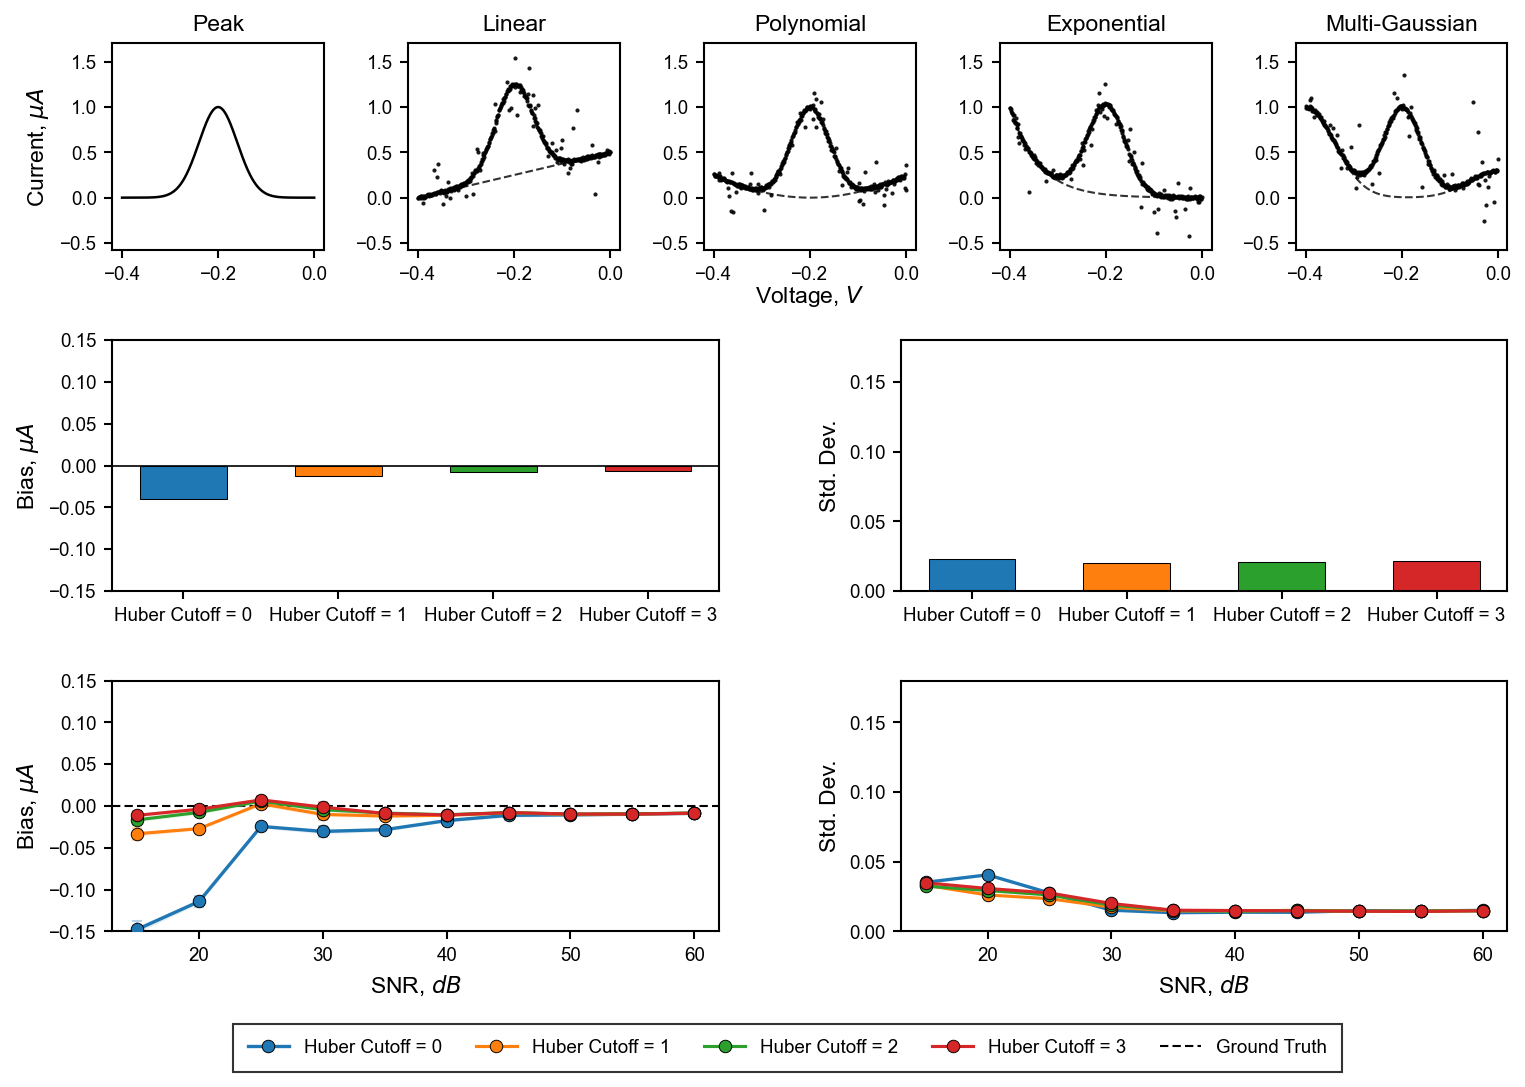

In [6]:
panel_summary_path = Path("../simulation/simulation_data/paper_data/huber_summary.feather")
stats_df = pd.read_feather(panel_summary_path)
fig_si_10 = plot_si1(stats_df=stats_df)
plt.show()
save_figure(fig_si_10, "SI_10")